In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from astropy.io import fits
import astropy.table as table
from astropy.io import ascii

from astropy import units as u
from collections import Counter
import astropy.coordinates as coord

plt.style.use('/Users/apace/.matplotlib/stylelib/std.mplstyle')

In [3]:
from astroquery.gaia import Gaia

The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


In [18]:
from sklearn.mixture import GaussianMixture

In [28]:
import scipy.stats as stats

In [4]:
# dwarf_info_all = table.Table.read('https://raw.githubusercontent.com/apace7/local_volume_database/main/data/dwarf_mw.csv')
dwarf_info_all = table.Table.read('/Users/apace/Documents/local_volume_database/data/comb_all.csv')
dwarf_info = dwarf_info_all[dwarf_info_all['key']=='ngc_0288'][0]
ra0, dec0 = float(dwarf_info['ra']), float(dwarf_info['dec'])


In [ ]:
## initial downloading/loading of data

In [5]:
gc = coord.SkyCoord(ra=ra0*u.deg, dec=dec0*u.deg)

In [6]:
Gaia.ROW_LIMIT = -1 ## this allows you to download all objects within radius

In [ ]:
j = Gaia.cone_search_async(gc, radius=u.Quantity(1, u.deg)) ## this is cone search

In [ ]:
r = j.get_results()

In [7]:
## I skipped the downloading of the data here as I saved it from before
temp_table = np.load('/Users/apace/Downloads/ngc_0288.npy', allow_pickle=True)

In [ ]:
## visualize data

Text(0, 0.5, 'dec (deg)')

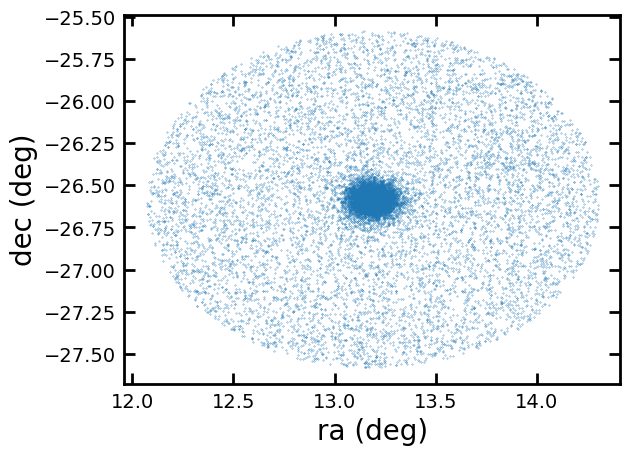

In [10]:
plt.plot(temp_table['ra'], temp_table['dec'], '.', ms=0.5)
plt.xlabel('ra (deg)')
plt.ylabel('dec (deg)')

In [14]:
## data cleaning/data selection, what data we are going to model
temp_table_pm_cut2 = temp_table[np.logical_and.reduce((temp_table['phot_g_mean_mag']<20, temp_table['ruwe']<1.4, temp_table['astrometric_excess_noise_sig']<2, temp_table['astrometric_params_solved']>3, temp_table['parallax']<1, np.sqrt(temp_table['pmra']**2 + temp_table['pmdec']**2) < 20))]
len(temp_table_pm_cut2), len(temp_table)

(8189, 23465)

Text(0, 0.5, 'pmdec (mas/yr)')

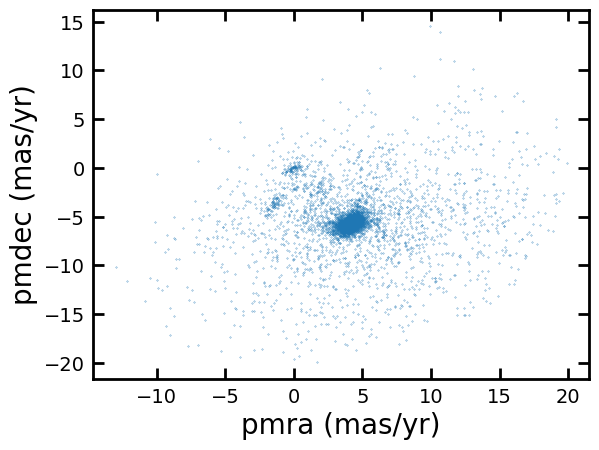

In [15]:
## more data visualization.
plt.plot(temp_table_pm_cut2['pmra'], temp_table_pm_cut2['pmdec'], '.', ms=0.5)
plt.xlabel('pmra (mas/yr)')
plt.ylabel('pmdec (mas/yr)')

In [16]:
data = np.array([temp_table_pm_cut2['pmra'], temp_table_pm_cut2['pmdec']])

In [53]:
## https://scikit-learn.org/stable/modules/mixture.html#gaussian-mixture-models

In [22]:
## Gaussian mixture with scikit-learn
gm = GaussianMixture(n_components=20, random_state=0).fit(data.T)
## 20 components was arbitary 

Text(0, 0.5, 'pmdec (mas/yr)')

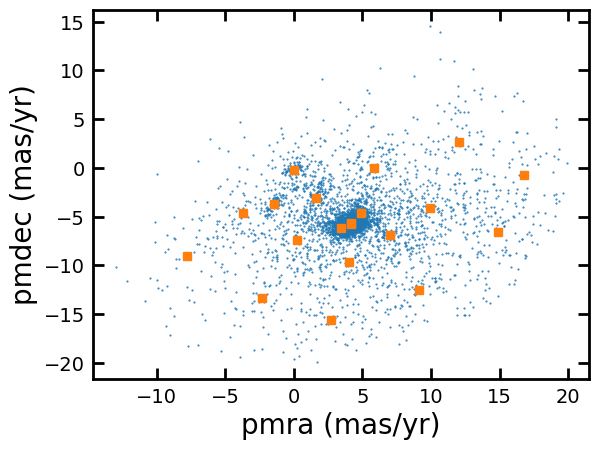

In [70]:
plt.plot(temp_table_pm_cut2['pmra'], temp_table_pm_cut2['pmdec'], '.', ms=1)
plt.plot(gm.means_.T[0], gm.means_.T[1], 's')
plt.xlabel('pmra (mas/yr)')
plt.ylabel('pmdec (mas/yr)')

In [25]:
## pmra, pmdec of each GMM term
gm.means_

array([[ 4.15102996e+00, -5.71243067e+00],
       [ 1.61034098e+00, -3.11540834e+00],
       [ 1.67570183e+01, -7.20314811e-01],
       [ 4.03430236e+00, -9.60329684e+00],
       [ 2.65228717e-01, -7.41610124e+00],
       [ 9.93178828e+00, -4.08063595e+00],
       [ 5.84065575e+00, -3.26963655e-02],
       [ 1.48621709e+01, -6.61821277e+00],
       [ 2.68468826e+00, -1.55656461e+01],
       [ 6.97670705e+00, -6.84957888e+00],
       [-1.41374722e+00, -3.67768391e+00],
       [-7.78878908e+00, -9.00499233e+00],
       [ 4.19918580e+00, -5.62689255e+00],
       [ 1.20520406e+01,  2.62774271e+00],
       [ 9.09888669e+00, -1.25084489e+01],
       [ 3.45780863e+00, -6.17892097e+00],
       [-3.67780208e+00, -4.63724701e+00],
       [-3.79821043e-03, -1.96142927e-01],
       [ 4.87870006e+00, -4.60336823e+00],
       [-2.32106923e+00, -1.33508743e+01]])

In [26]:
## dispersion terms 
# (sigma_pmra cross term)
# (cross term sigma_pmdec)
gm.covariances_

array([[[ 0.04776007,  0.02327451],
        [ 0.02327451,  0.05580753]],

       [[ 0.8611574 ,  0.30565493],
        [ 0.30565493,  2.76733624]],

       [[ 3.19437149,  0.47650736],
        [ 0.47650736, 13.54616229]],

       [[ 4.29331628, -0.37881234],
        [-0.37881234,  2.23837185]],

       [[ 2.73830312, -0.44893158],
        [-0.44893158,  6.20163525]],

       [[ 5.26205497,  0.28351425],
        [ 0.28351425,  2.47191697]],

       [[ 5.83127   , -2.322664  ],
        [-2.322664  ,  8.42616874]],

       [[ 3.51902137,  1.26965262],
        [ 1.26965262,  7.83946938]],

       [[ 8.20543795,  1.75649057],
        [ 1.75649057,  4.27563812]],

       [[ 3.99470485, -1.32176725],
        [-1.32176725,  2.49659929]],

       [[ 0.16814467,  0.20123359],
        [ 0.20123359,  0.45395471]],

       [[ 4.67804773,  2.42350985],
        [ 2.42350985, 14.44139701]],

       [[ 0.21344078,  0.07946464],
        [ 0.07946464,  0.26093629]],

       [[ 3.11248557, -1.28266283],
  

In [27]:
## weight of each component
gm.weights_


array([0.37739041, 0.02667013, 0.00665875, 0.01766384, 0.02258156,
       0.01939812, 0.02843772, 0.01189778, 0.01050089, 0.02824454,
       0.01018718, 0.00575994, 0.27192309, 0.01088528, 0.01403388,
       0.05812258, 0.01547979, 0.01554985, 0.0424004 , 0.00621427])

In [ ]:
## the highest value is the GC, but some large components are the GC broken into multiple components because of how much it dominates this field

In [29]:
pmra_range = np.arange(-10, 20, .01)

pmra_tot = []

for i in pmra_range:
    pmra_temp =0.
    for jj in range(20):
        pmra_temp += gm.weights_[jj] * stats.norm.pdf(i, gm.means_[jj][0], gm.covariances_[jj][0][0])
    
    pmra_tot.append(pmra_temp )

pmra_tot = np.array(pmra_tot)


Text(0, 0.5, 'Number')

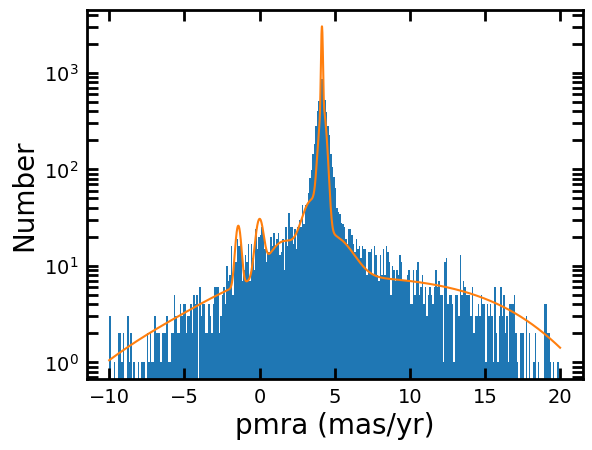

In [34]:
x = plt.hist(temp_table_pm_cut2['pmra'], bins=np.arange(-10, 20, .1))
plt.yscale('log')
plt.plot(pmra_range, pmra_tot*len(temp_table_pm_cut2)*.1 )
## I think this normalization is ok (number of stars * bin size)
plt.xlabel('pmra (mas/yr)')
plt.ylabel('Number')

In [38]:
pmdec_tot = []
pmdec_range = np.arange(-15, 10, .01)
for i in pmdec_range:
    pmdec_temp =0.
    for jj in range(20):
        pmdec_temp += gm.weights_[jj] * stats.norm.pdf(i, gm.means_[jj][1], gm.covariances_[jj][1][1])
    
    pmdec_tot.append(pmdec_temp )

pmdec_tot = np.array(pmdec_tot)

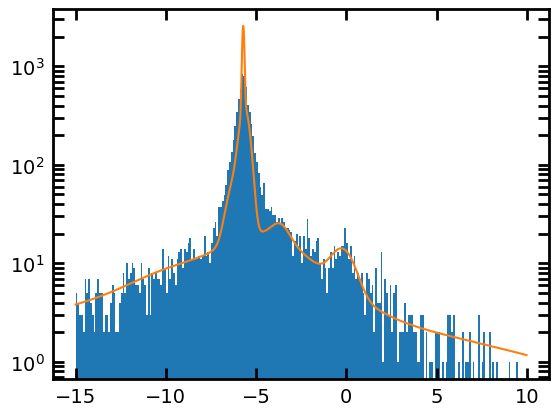

In [39]:
x = plt.hist(temp_table_pm_cut2['pmdec'], bins=np.arange(-15, 10, .1))
plt.yscale('log')
plt.plot(pmdec_range, pmdec_tot*len(temp_table_pm_cut2)*.1)
plt.xlabel('pmdec (mas/yr)')
plt.ylabel('Number')

In [ ]:
## breaking the data into components 
## as you can see, 20 Gaussians is probably overkill 

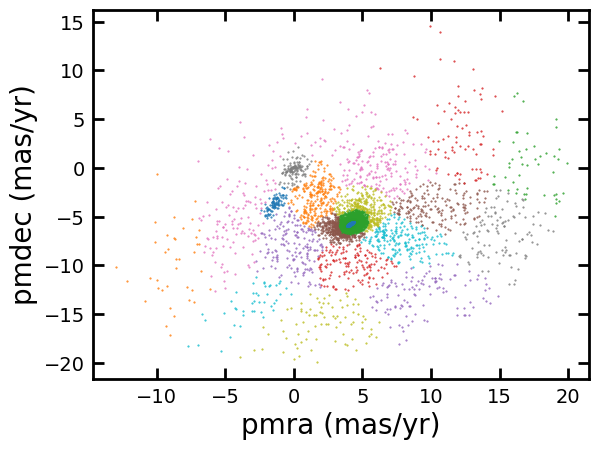

In [68]:
for i in range(20):
    pop1 = data.T[gm.predict(data.T )==i]
    plt.plot(pop1.T[0], pop1.T[1], '.', ms=1)
plt.xlabel('pmra (mas/yr)')
plt.ylabel('pmdec (mas/yr)')
plt.show()

In [51]:
## https://scikit-learn.org/stable/modules/generated/sklearn.mixture.BayesianGaussianMixture.html#bayesiangaussianmixture

In [40]:
from sklearn.mixture import BayesianGaussianMixture

In [63]:
bgm = BayesianGaussianMixture(n_components=10, random_state=0, ).fit(data.T)
## weight_concentration_prior=1

/Users/apace/miniconda3/envs/fix_env/lib/python3.14/site-packages/sklearn/mixture/_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


In [64]:
bgm.weights_

array([0.48353891, 0.03906982, 0.03178379, 0.04726929, 0.05149075,
       0.2358937 , 0.04567207, 0.03427656, 0.01689209, 0.01411301])

In [60]:
bgm.means_

array([[ 4.15782163e+00, -5.70306257e+00],
       [ 7.68425430e-01, -1.77222541e+00],
       [ 1.25847038e+01, -1.08557057e+00],
       [ 3.35139192e+00, -8.65235700e+00],
       [-1.05218785e-03, -4.90397823e+00],
       [ 4.11719072e+00, -5.68221106e+00],
       [ 6.11029574e+00, -3.76157360e+00],
       [ 7.96890433e+00, -4.96217441e+00],
       [-2.34592485e+00, -1.24578229e+01],
       [ 1.03171618e+01, -1.03579736e+01]])

In [50]:
bgm.covariances_

array([[[ 0.11426115,  0.05110469],
        [ 0.05110469,  0.13473109]],

       [[ 6.24745983, -2.85991541],
        [-2.85991541,  5.28614561]],

       [[37.29513608,  7.91417171],
        [ 7.91417171, 29.18274021]]])